In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [3]:
# Cargar el dataset (asegúrate de tener el archivo ENB2012_data.xlsx en la misma carpeta)
# El dataset suele tener columnas X1...X8 (características) e Y1, Y2 (objetivos)
# Carga directa desde la URL oficial del dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
# Seleccionamos las 8 características de entrada y la variable objetivo 'heating_load' (Y1)
X = df.iloc[:, :8].values
y = df.iloc[:, 8].values # Y1 es Heating Load

print(f"Forma de las entradas (X): {X.shape}")
print(f"Forma del objetivo (y): {y.shape}")

Forma de las entradas (X): (768, 8)
Forma del objetivo (y): (768,)


In [4]:
# 4. División en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Escalado con StandardScaler
scaler = StandardScaler()

# Ajustar el scaler solo con los datos de entrenamiento y transformar ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente.")

Datos escalados correctamente.


In [5]:
# 6. Construcción del modelo base
base_model = Sequential([
    Dense(16, activation='relu', input_shape=(8,)), # Capa densa 1
    Dense(8, activation='relu'),                    # Capa densa 2
    Dense(1)                                        # Salida para regresión (sin activación)
])

# 7. Compilación
base_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 8. Entrenamiento con validation_split
history_base = base_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0 # Silencioso para no llenar el notebook
)

# 9. Evaluación en test
mae_base = base_model.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f"MAE obtenido en el Modelo Base: {mae_base:.4f}")

c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MAE obtenido en el Modelo Base: 2.0223


In [6]:
# Aplicamos: Más neuronas, una capa adicional, Dropout y EarlyStopping
improved_model = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dropout(0.1),                  # Técnica 1: Dropout
    Dense(16, activation='relu'),  # Técnica 2: Capa adicional
    Dense(1)
])

improved_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Técnica 3: EarlyStopping para evitar el sobreentrenamiento
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_improved = improved_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

mae_improved = improved_model.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f"MAE obtenido en el Modelo Mejorado: {mae_improved:.4f}")

MAE obtenido en el Modelo Mejorado: 0.8088


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


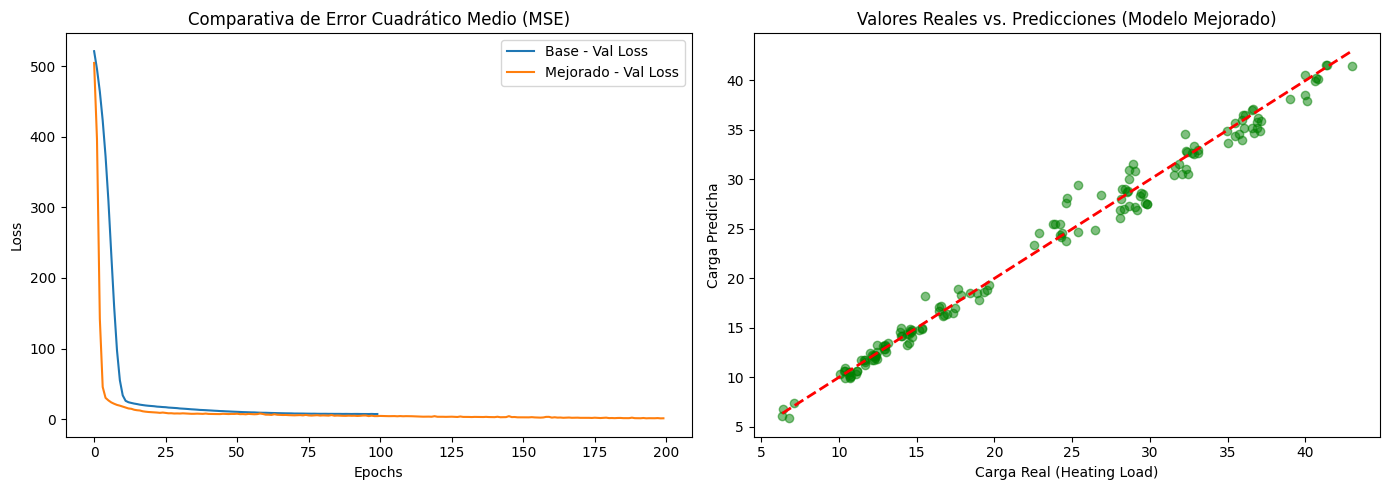

In [7]:
plt.figure(figsize=(14, 5))

# Gráfica de curvas de pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history_base.history['val_loss'], label='Base - Val Loss')
plt.plot(history_improved.history['val_loss'], label='Mejorado - Val Loss')
plt.title('Comparativa de Error Cuadrático Medio (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Gráfica de Valores Reales vs Predichos (usando el modelo mejorado)
y_pred = improved_model.predict(X_test_scaled)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valores Reales vs. Predicciones (Modelo Mejorado)')
plt.xlabel('Carga Real (Heating Load)')
plt.ylabel('Carga Predicha')
plt.tight_layout()
plt.show()

El modelo mejorado generaliza mejor al presentar un MAE más bajo en el conjunto de test y una curva de pérdida de validación más estable. Lo he comprobado evaluando ambos modelos con datos nunca vistos (test) y comparando sus métricas finales. No se observan indicios graves de overfitting en el modelo mejorado gracias al uso de EarlyStopping y Dropout, que mantuvieron la pérdida de entrenamiento y validación cercanas entre sí; en cambio, el modelo base mostró una ligera divergencia al final del entrenamiento.